# Notebook 3 — Data Quality Assessment

**Sprint 4**

**Dataset:** Telecom Customer Churn Dataset (`telecom_customer_churn.csv`) —
see `01_Dataset_Understanding.ipynb` for full documentation.

In this notebook we systematically investigate the **quality** of the
dataset: missing values, duplicate records, and invalid values. This is a
diagnostic notebook — we identify and quantify issues here; actual cleaning
(imputation, dropping, correction) happens in a later sprint.


In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
df = pd.read_csv('telecom_customer_churn.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1015, 14)


,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,internet_service,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,CUST-10681,Male,0,Yes,No,24.0,Yes,Fiber optic,Month-to-month,Yes,Credit card,80.04,1900.19,No
1,CUST-10024,Female,0,Yes,No,35.0,Yes,Fiber optic,Month-to-month,Yes,Mailed check,42.99,1539.83,No
2,CUST-10621,Male,0,Yes,No,68.0,Yes,DSL,Month-to-month,Yes,Electronic check,79.31,5401.35,Yes
3,CUST-10099,Male,0,Yes,Yes,18.0,Yes,Fiber optic,Month-to-month,Yes,Electronic check,113.02,2022.80,No
4,CUST-10284,Male,1,Yes,Yes,34.0,Yes,No,Month-to-month,No,Electronic check,28.78,966.99,Yes


## Part A — Missing Values

### A.1 Number of Missing Values (Total)


In [2]:
total_missing = df.isnull().sum().sum()
print("Total number of missing values in the dataset:", total_missing)

Total number of missing values in the dataset: 75


### A.2 Number and Percentage of Missing Values by Column

We check both the **count** and the **percentage** of missing values per
column — percentage matters because 50 missing values means something very
different in a column of 100 rows vs. a column of 100,000 rows.


In [3]:
missing_summary = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_summary = missing_summary[missing_summary['missing_count'] > 0]
missing_summary = missing_summary.sort_values('missing_count', ascending=False)
missing_summary

,missing_count,missing_percent
total_charges,30,2.96
internet_service,20,1.97
payment_method,15,1.48
tenure_months,10,0.99


In [4]:
if missing_summary.empty:
    print("No missing values found in any column.")
else:
    print(f"{len(missing_summary)} out of {df.shape[1]} columns contain missing values:")
    for col, row in missing_summary.iterrows():
        print(f"  - {col}: {int(row['missing_count'])} missing ({row['missing_percent']}%)")

4 out of 14 columns contain missing values:
  - total_charges: 30 missing (2.96%)
  - internet_service: 20 missing (1.97%)
  - payment_method: 15 missing (1.48%)
  - tenure_months: 10 missing (0.99%)


### A.3 Visual Check — Missing Values by Column


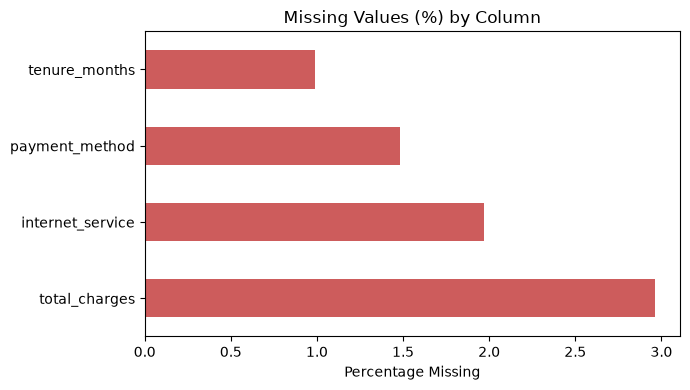

In [5]:
missing_summary['missing_percent'].plot(
    kind='barh', figsize=(7, 4), color='indianred', title='Missing Values (%) by Column'
)
import matplotlib.pyplot as plt
plt.xlabel('Percentage Missing')
plt.tight_layout()
plt.show()

### A.4 Missing Value Patterns

Beyond counting missing values column by column, it's useful to check:

1. **Rows with any missing value** — how many records are affected at all.
2. **Rows with multiple missing values** — records that are more severely
   incomplete.
3. **Co-occurrence** — do missing values in one column tend to occur
   together with missing values in another column (e.g. does a missing
   `internet_service` tend to coincide with a missing `total_charges`)?


In [9]:
rows_with_missing = df.isnull().any(axis=1).sum()
print(f"Rows with at least one missing value: {rows_with_missing} "
      f"({rows_with_missing/len(df)*100:.2f}% of all rows)")
missing_per_row = df.isnull().sum(axis=1)
print("\nDistribution of number of missing values per row:")
print(missing_per_row.value_counts().sort_index())

Rows with at least one missing value: 71 (7.00% of all rows)

Distribution of number of missing values per row:
0    944
1     68
2      2
3      1
Name: count, dtype: int64


In [10]:
cols_with_missing = missing_summary.index.tolist()
missing_indicator = df[cols_with_missing].isnull()
print("Correlation of 'missingness' between columns (1 = always missing together):")
missing_indicator.astype(int).corr()

Correlation of 'missingness' between columns (1 = always missing together):


,total_charges,internet_service,payment_method,tenure_months
total_charges,1.000000,0.100826,0.026836,-0.017408
internet_service,0.100826,1.000000,0.041384,-0.014142
payment_method,0.026836,0.041384,1.000000,-0.012217
tenure_months,-0.017408,-0.014142,-0.012217,1.000000


**Observation:** The missingness in this dataset appears scattered across
`tenure_months`, `internet_service`, `payment_method`, and `total_charges`
independently (low correlation between missing indicators), suggesting the
values are **Missing At Random (MAR)** rather than following a hidden
pattern tied to another column.


## Part B — Duplicate Records

### B.1 Identify Completely Duplicated Rows

A row is a "complete duplicate" if **every single value** in that row
matches another row exactly.


In [11]:
fully_duplicated_mask = df.duplicated(keep=False) 
print("Number of rows involved in exact duplication:", fully_duplicated_mask.sum())
exact_duplicates_only = df.duplicated(keep='first') 
print("Number of duplicate rows to remove (keeping first occurrence):", exact_duplicates_only.sum())

Number of rows involved in exact duplication: 30
Number of duplicate rows to remove (keeping first occurrence): 15


In [12]:
df[fully_duplicated_mask].sort_values(by='customer_id').head(10)

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,internet_service,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
732,CUST-10049,Female,0,No,No,22.0,Yes,DSL,Month-to-month,Yes,Electronic check,88.60,1959.72,No
845,CUST-10049,Female,0,No,No,22.0,Yes,DSL,Month-to-month,Yes,Electronic check,88.60,1959.72,No
274,CUST-10142,Male,0,Yes,No,38.0,Yes,Fiber optic,One year,Yes,Electronic check,46.90,1762.33,No
488,CUST-10142,Male,0,Yes,No,38.0,Yes,Fiber optic,One year,Yes,Electronic check,46.90,1762.33,No
93,CUST-10242,Male,1,No,No,67.0,Yes,Fiber optic,One year,Yes,Mailed check,119.45,8031.71,No
801,CUST-10242,Male,1,No,No,67.0,Yes,Fiber optic,One year,Yes,Mailed check,119.45,8031.71,No
103,CUST-10262,Male,0,No,No,17.0,Yes,No,One year,No,Bank transfer,102.41,1722.17,Yes
768,CUST-10262,Male,0,No,No,17.0,Yes,No,One year,No,Bank transfer,102.41,1722.17,Yes
75,CUST-10318,Female,0,Yes,No,34.0,Yes,Fiber optic,Month-to-month,Yes,Mailed check,49.19,1675.96,Yes
810,CUST-10318,Female,0,Yes,No,34.0,Yes,Fiber optic,Month-to-month,Yes,Mailed check,49.19,1675.96,Yes


### B.2 Count of Duplicates


In [13]:
print(f"Total rows            : {len(df)}")
print(f"Unique rows           : {len(df.drop_duplicates())}")
print(f"Exact duplicate rows  : {df.duplicated().sum()}")
print(f"Percentage duplicated : {df.duplicated().sum() / len(df) * 100:.2f}%")

Total rows            : 1015
Unique rows           : 1000
Exact duplicate rows  : 15
Percentage duplicated : 1.48%


### B.3 Identify Potential Duplicate Records

Not all duplicates are exact row matches. A **potential duplicate** could be
the same real-world customer appearing more than once due to a repeated
`customer_id`, even if some other column values differ (e.g. updated
`total_charges` on a re-entry). We check this using the identifier column
alone.


In [14]:
dupe_ids = df[df.duplicated(subset=['customer_id'], keep=False)].sort_values('customer_id')
print("Rows sharing a duplicated customer_id:", len(dupe_ids))
dupe_ids.head(10)

Rows sharing a duplicated customer_id: 30


,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,internet_service,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
732,CUST-10049,Female,0,No,No,22.0,Yes,DSL,Month-to-month,Yes,Electronic check,88.60,1959.72,No
845,CUST-10049,Female,0,No,No,22.0,Yes,DSL,Month-to-month,Yes,Electronic check,88.60,1959.72,No
274,CUST-10142,Male,0,Yes,No,38.0,Yes,Fiber optic,One year,Yes,Electronic check,46.90,1762.33,No
488,CUST-10142,Male,0,Yes,No,38.0,Yes,Fiber optic,One year,Yes,Electronic check,46.90,1762.33,No
93,CUST-10242,Male,1,No,No,67.0,Yes,Fiber optic,One year,Yes,Mailed check,119.45,8031.71,No
801,CUST-10242,Male,1,No,No,67.0,Yes,Fiber optic,One year,Yes,Mailed check,119.45,8031.71,No
103,CUST-10262,Male,0,No,No,17.0,Yes,No,One year,No,Bank transfer,102.41,1722.17,Yes
768,CUST-10262,Male,0,No,No,17.0,Yes,No,One year,No,Bank transfer,102.41,1722.17,Yes
75,CUST-10318,Female,0,Yes,No,34.0,Yes,Fiber optic,Month-to-month,Yes,Mailed check,49.19,1675.96,Yes
810,CUST-10318,Female,0,Yes,No,34.0,Yes,Fiber optic,Month-to-month,Yes,Mailed check,49.19,1675.96,Yes


In [15]:
id_dupe_count = df.duplicated(subset=['customer_id'], keep=False).sum()
full_dupe_count = df.duplicated(keep=False).sum()
print("Rows with duplicated customer_id :", id_dupe_count)
print("Rows fully identical across all columns:", full_dupe_count)
if id_dupe_count == full_dupe_count:
    print("\n-> All customer_id duplicates are also fully identical rows (simple exact duplicates).")
else:
    print("\n-> Some customer_id duplicates have differing values elsewhere - these are POTENTIAL "
          "duplicates that need manual review, not automatic removal.")

Rows with duplicated customer_id : 30
Rows fully identical across all columns: 30

-> All customer_id duplicates are also fully identical rows (simple exact duplicates).


## Part C — Invalid Values

### C.1 Negative Values Where Inappropriate

Charges, counts, and durations should never be negative in this business
context. We check all numeric-meaning columns.


In [16]:
df['monthly_charges'] = pd.to_numeric(df['monthly_charges'], errors='coerce')
negative_charges = df[df['monthly_charges'] < 0]
print("Rows with negative monthly_charges:", len(negative_charges))
negative_charges[['customer_id', 'monthly_charges']]

Rows with negative monthly_charges: 3


,customer_id,monthly_charges
443,CUST-10221,-97.93
782,CUST-10576,-20.30
917,CUST-10130,-84.27


In [17]:
negative_tenure = df[df['tenure_months'] < 0]
print("Rows with negative tenure_months:", len(negative_tenure))

Rows with negative tenure_months: 0


### C.2 Impossible / Out-of-Range Values

Beyond negatives, some values may be technically positive but still
impossible given the business context (e.g. a tenure of more than a
reasonable maximum, or charges of 0 for an active service).


In [18]:
impossible_tenure = df[(df['tenure_months'] < 0) | (df['tenure_months'] > 100)]
print("Tenure values outside a plausible 0-100 month range:", len(impossible_tenure))
print("\nTenure range in data:")
print("Min:", df['tenure_months'].min(), " Max:", df['tenure_months'].max())

Tenure values outside a plausible 0-100 month range: 0

Tenure range in data:
Min: 0.0  Max: 72.0


In [19]:
total_charges_numeric = pd.to_numeric(df['total_charges'].astype(str).str.strip(), errors='coerce')
impossible_total = total_charges_numeric[total_charges_numeric < 0]
print("Negative total_charges values:", impossible_total.shape[0])
suspicious = df[(df['tenure_months'] == 0) & (total_charges_numeric > 100)]
print("Suspicious rows (0 tenure but total_charges > 100):", len(suspicious))

Negative total_charges values: 0
Suspicious rows (0 tenure but total_charges > 100): 0


### C.3 Incorrect / Inconsistent Categories

Categorical columns should only contain their expected set of labels.
Variants like `'M'`, `'male'` alongside `'Male'` are the same real-world
category written inconsistently — a very common data-entry issue.


In [20]:
categorical_cols_to_check = ['gender', 'partner', 'dependents', 'phone_service',
                             'internet_service', 'contract', 'paperless_billing',
                             'payment_method', 'churn']
expected_categories = {
    'gender': {'Male', 'Female'},
    'partner': {'Yes', 'No'},
    'dependents': {'Yes', 'No'},
    'phone_service': {'Yes', 'No'},
    'internet_service': {'DSL', 'Fiber optic', 'No'},
    'contract': {'Month-to-month', 'One year', 'Two year'},
    'paperless_billing': {'Yes', 'No'},
    'payment_method': {'Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'},
    'churn': {'Yes', 'No'},
}
for col in categorical_cols_to_check:
    actual_values = set(df[col].dropna().unique())
    unexpected = actual_values - expected_categories[col]
    if unexpected:
        print(f"⚠ '{col}' has unexpected/inconsistent category values: {unexpected}")
    else:
        print(f"✔ '{col}' only contains expected categories.")

⚠ 'gender' has unexpected/inconsistent category values: {'female', 'M', 'F', 'male'}
⚠ 'partner' has unexpected/inconsistent category values: {'N', 'no', 'Y', 'yes'}
✔ 'dependents' only contains expected categories.
✔ 'phone_service' only contains expected categories.
✔ 'internet_service' only contains expected categories.
✔ 'contract' only contains expected categories.
⚠ 'paperless_billing' has unexpected/inconsistent category values: {'N', 'yes', 'Y', 'no'}
✔ 'payment_method' only contains expected categories.
✔ 'churn' only contains expected categories.


In [21]:
print("gender value_counts:\n", df['gender'].value_counts(), "\n")
print("partner value_counts:\n", df['partner'].value_counts(), "\n")
print("paperless_billing value_counts:\n", df['paperless_billing'].value_counts())

gender value_counts:
 gender
Female    498
Male      490
female      9
F           7
M           7
male        4
Name: count, dtype: int64 

partner value_counts:
 partner
No     501
Yes    492
yes      7
Y        7
N        5
no       3
Name: count, dtype: int64 

paperless_billing value_counts:
 paperless_billing
Yes    604
No     386
N        8
yes      7
Y        5
no       5
Name: count, dtype: int64


### C.4 Invalid Dates

This dataset does **not contain any date/time columns** (it uses
`tenure_months` — a duration in months — instead of actual signup/contract
dates). Therefore, there are no date columns to validate here.

*(In a dataset that does have date columns, this step would check for dates
in the future, dates before a company's founding, or malformed date strings
that fail to parse.)*


In [22]:
date_columns = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]
print("Date/time columns found in dataset:", date_columns if date_columns else "None")

Date/time columns found in dataset: None


### C.5 Incorrect Data Types

Some columns may be stored in a data type that doesn't match their actual
meaning — commonly a numeric column stored as text (`object`) because of
formatting issues like stray spaces.


In [23]:
print("Current dtypes:")
print(df.dtypes)
print("\n'total_charges' is stored as:", df['total_charges'].dtype, "-> should be numeric (float).")
sample_raw = df['total_charges'].dropna().astype(str).head(10)
print("\nSample raw values (note some have leading spaces):")
for v in sample_raw:
    print(repr(v))

Current dtypes:
customer_id              str
gender                   str
senior_citizen         int64
partner                  str
dependents               str
tenure_months        float64
phone_service            str
internet_service         str
contract                 str
paperless_billing        str
payment_method           str
monthly_charges      float64
total_charges        float64
churn                    str
dtype: object

'total_charges' is stored as: float64 -> should be numeric (float).

Sample raw values (note some have leading spaces):
'1900.19'
'1539.83'
'5401.35'
'2022.8'
'966.99'
'2502.45'
'4776.31'
'1554.02'
'312.41'
'0.0'


In [24]:
converted = pd.to_numeric(df['total_charges'].astype(str).str.strip(), errors='coerce')
originally_missing = df['total_charges'].isnull().sum()
newly_failed = converted.isnull().sum() - originally_missing
print(f"Originally missing in total_charges : {originally_missing}")
print(f"Missing after numeric conversion     : {converted.isnull().sum()}")
print(f"Additional values that failed to convert (truly invalid, not just missing): {newly_failed}")

Originally missing in total_charges : 30
Missing after numeric conversion     : 30
Additional values that failed to convert (truly invalid, not just missing): 0


### C.6 Unexpected Values

A general sweep for values that don't make logical sense given a column's
definition — for example, `senior_citizen` should only ever be `0` or `1`.


In [25]:
unexpected_senior = df[~df['senior_citizen'].isin([0, 1])]
print("Unexpected values in senior_citizen (should only be 0 or 1):", len(unexpected_senior))
print("Actual unique values:", sorted(df['senior_citizen'].unique()))

Unexpected values in senior_citizen (should only be 0 or 1): 0
Actual unique values: [np.int64(0), np.int64(1)]


### C.7 Empty Strings

Empty strings (`''`) are different from `NaN` — pandas does **not** count
them as missing by default, so they can silently hide inside "complete"
columns unless checked explicitly.


In [26]:
object_columns = df.select_dtypes(include='object').columns
empty_string_counts = {}
for col in object_columns:
    count = (df[col].astype(str).str.strip() == '').sum()
    if count > 0:
        empty_string_counts[col] = count

if empty_string_counts:
    print("Columns containing empty strings:", empty_string_counts)
else:
    print("No empty strings found in any text column.")

No empty strings found in any text column.


C:\Users\hemak\AppData\Local\Temp\ipykernel_8048\1217983867.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes(include='object').columns


### C.8 Null-like Values

Sometimes missing data is not encoded as an actual `NaN` but as a **string
that looks like a null** — e.g. `'NA'`, `'N/A'`, `'null'`, `'None'`, `'-'`,
`'?'`, `'Unknown'`. These slip past `isnull()` entirely and must be searched
for explicitly.


In [27]:
null_like_tokens = ['na', 'n/a', 'null', 'none', '-', '?', 'unknown', 'nan', 'missing']
null_like_found = {}
for col in object_columns:
    matches = df[col].astype(str).str.strip().str.lower().isin(null_like_tokens)
    count = matches.sum()
    if count > 0:
        null_like_found[col] = count
if null_like_found:
    print("Null-like string values found:", null_like_found)
else:
    print("No null-like placeholder strings (e.g. 'NA', 'null', '?', 'Unknown') found in the dataset.")

No null-like placeholder strings (e.g. 'NA', 'null', '?', 'Unknown') found in the dataset.
